# Oasis Infobyte Internship

# Task 5: Sales Prediction Using Python

## Internship Domain
**Data Science**

---

## Project Overview

Sales prediction is one of the most important applications of machine learning in business analytics. Companies invest in different advertising channels such as Television, Radio, and Newspaper to promote their products. Understanding how these advertising expenditures influence product sales helps businesses optimize their marketing strategies and improve profitability.

In this project, we develop regression models to predict product sales based on advertising budgets across different media channels. The project includes data cleaning, exploratory data analysis (EDA), model training, evaluation, and interpretation of feature importance.

---

## Objectives

- Load and inspect the advertising dataset
- Perform data cleaning and preprocessing
- Analyze relationships between advertising channels and sales
- Train multiple regression models
- Evaluate model performance
- Compare different regression algorithms
- Identify the advertising channel with the greatest impact on sales

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab (Jupyter Notebook)

---

## Dataset

**Advertising.csv**

---

## Author

**Anirban Garai**

Oasis Infobyte Internship

In [31]:
# ==========================================
# Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Importing Libraries

The following Python libraries are required for this project.

### NumPy
Used for numerical computations.

### Pandas
Used for loading, cleaning, and manipulating datasets.

### Matplotlib
Used for creating visualizations.

### Seaborn
Used for advanced statistical graphics and exploratory data analysis.

Scikit-learn libraries will be imported later during the machine learning phase.

In [32]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# Loading the Dataset

The dataset contains advertising expenditures across different media channels along with the corresponding product sales.

The advertising channels include:

- TV
- Radio
- Newspaper

The objective is to predict product sales based on these advertising budgets.

In [33]:
# Load Dataset

df = pd.read_csv("Advertising.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


# Display Dataset

Let's display the first few rows of the dataset to understand its structure.

In [34]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


# Dataset Information

The `info()` function provides useful information such as:

- Number of rows and columns
- Data types
- Missing values
- Memory usage

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


# Shape of Dataset

The shape tells us the number of observations and features available for analysis.

In [36]:
print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

Rows : 200
Columns : 5


# Column Names

Let's inspect the available columns in the dataset.

In [37]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

# Data Types

Checking data types helps distinguish numerical and categorical variables before analysis.

In [38]:
df.dtypes

,0
Unnamed: 0,int64
TV,float64
Radio,float64
Newspaper,float64
Sales,float64


# Statistical Summary

The `describe()` function provides summary statistics including:

- Count
- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

These statistics help us understand the distribution of numerical features.

In [39]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


# Display Last 10 Records

Viewing the last few rows helps verify that the dataset has been loaded correctly.

In [40]:
df.tail(10)

,Unnamed: 0,TV,Radio,Newspaper,Sales
190,191,39.5,41.1,5.8,10.8
191,192,75.5,10.8,6.0,9.9
192,193,17.2,4.1,31.6,5.9
193,194,166.8,42.0,3.6,19.6
194,195,149.7,35.6,6.0,17.3
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


# Sample Records

Displaying random samples provides another quick overview of the dataset.

In [41]:
df.sample(10)

,Unnamed: 0,TV,Radio,Newspaper,Sales
3,4,151.5,41.3,58.5,18.5
178,179,276.7,2.3,23.7,11.8
76,77,27.5,1.6,20.7,6.9
12,13,23.8,35.1,65.9,9.2
182,183,56.2,5.7,29.7,8.7
69,70,216.8,43.9,27.2,22.3
117,118,76.4,0.8,14.8,9.4
189,190,18.7,12.1,23.4,6.7
159,160,131.7,18.4,34.6,12.9
49,50,66.9,11.7,36.8,9.7


# Checking Basic Dataset Information

Let's inspect the dimensions of the dataset and count the number of unique values in each column.

In [42]:
print("Dataset Shape :", df.shape)

print("\nUnique Values\n")

for col in df.columns:
    print(col, ":", df[col].nunique())

Dataset Shape : (200, 5)

Unique Values

Unnamed: 0 : 200
TV : 190
Radio : 167
Newspaper : 172
Sales : 121


# Target Variable

The target variable for this regression problem is:

**Sales**

The machine learning models will learn the relationship between advertising budgets and product sales.

In [43]:
print("Target Variable :", "Sales")

Target Variable : Sales


# Dataset Overview

From the initial inspection, we understand:

- The dataset contains advertising expenditure across multiple media channels.
- Sales is the target variable to be predicted.
- All predictor variables are numerical.
- The dataset is ready for data cleaning and exploratory data analysis.

---

# Data Cleaning

Before building machine learning models, it is important to clean and inspect the dataset.

The following preprocessing steps will be performed:

- Check missing values
- Check duplicate records
- Remove duplicate records (if any)
- Remove unnecessary columns

In [44]:
# Checking Missing Values

df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


# Missing Values Analysis

Missing values can affect the accuracy of machine learning models.

Let's visualize them using a heatmap.

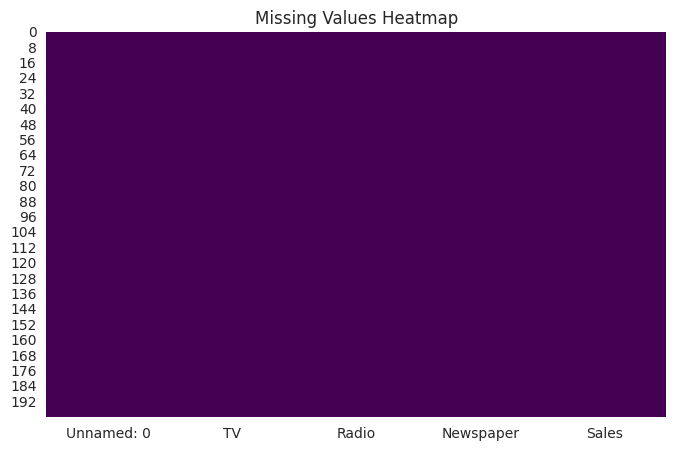

In [45]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

### Observation

- The dataset contains no missing values.
- Therefore, no missing value treatment is required before analysis.

# Duplicate Records

Duplicate records may affect model performance.

Let's check whether duplicate rows exist.

In [46]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


# Removing Duplicate Records

In [47]:
df = df.drop_duplicates()

print("New Shape :", df.shape)

New Shape : (200, 5)


# Removing Unnecessary Columns

Some versions of the Advertising dataset contain an index column named **Unnamed: 0**.

If it exists, we remove it because it does not contribute to predicting sales.

In [48]:
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


# Updated Dataset Information

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


---

# Exploratory Data Analysis (EDA)

EDA helps us understand the relationships between advertising budgets and product sales through visualizations.

# Distribution of Sales

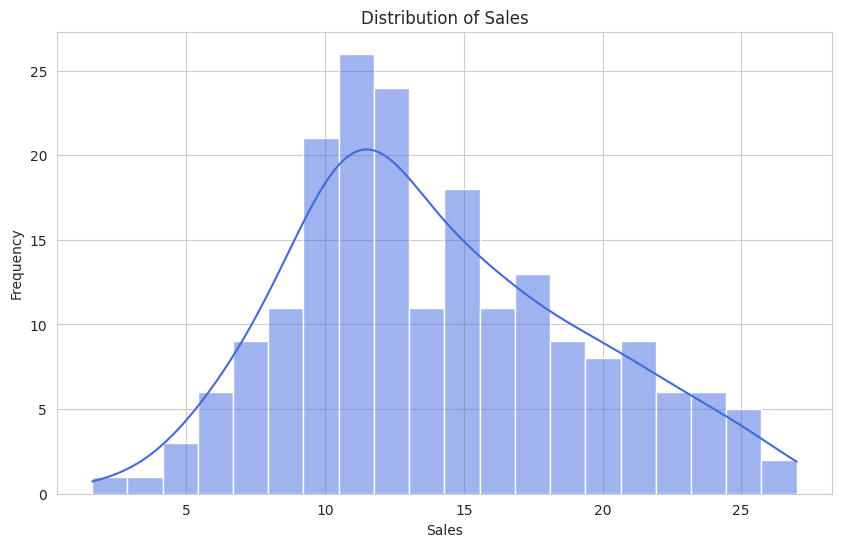

In [50]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Sales"],
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Sales")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

### Observation

- The histogram shows how sales values are distributed.
- Most observations are concentrated around the middle sales range.

# Pairplot

A pairplot visualizes relationships among all numerical variables in the dataset.

It helps identify trends, correlations, and potential outliers.

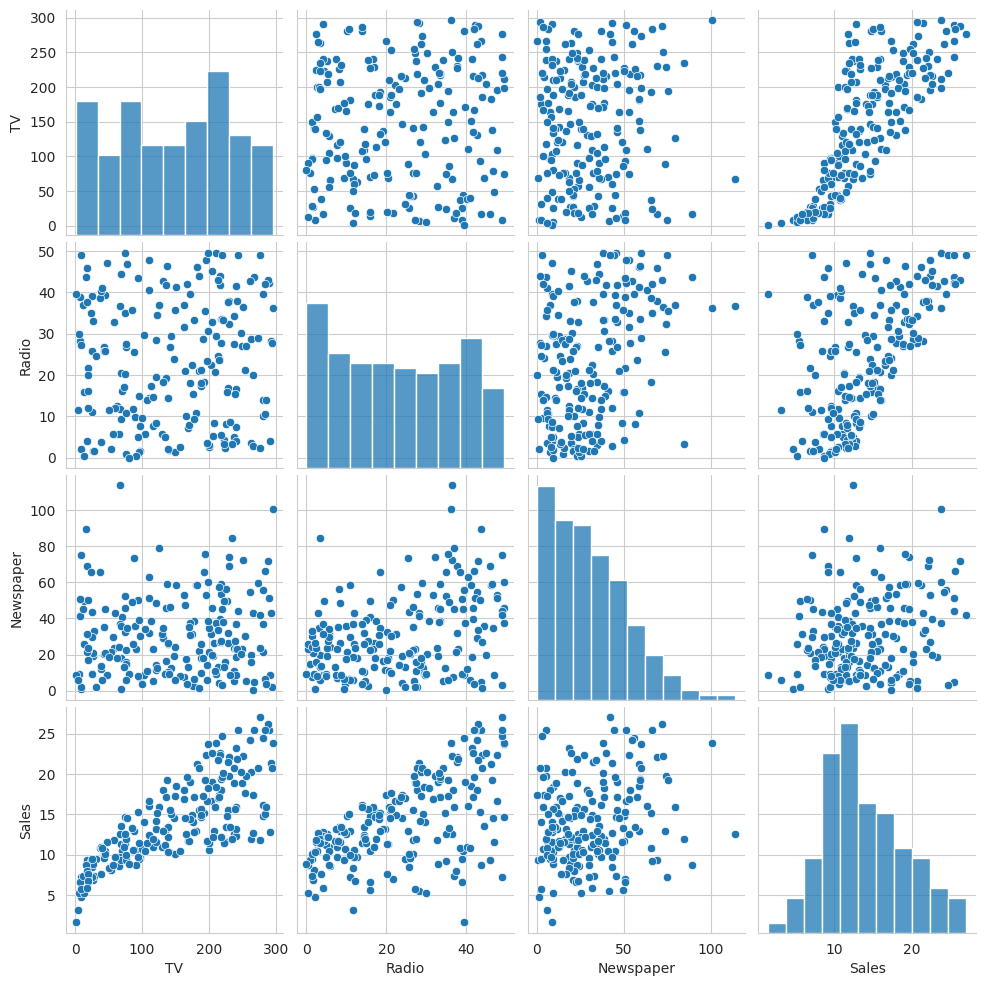

In [51]:
sns.pairplot(df)

plt.show()

### Observation

- The pairplot shows relationships among TV, Radio, Newspaper advertising, and Sales.
- Stronger linear relationships indicate variables that may be better predictors of sales.

# Sales vs TV Advertising

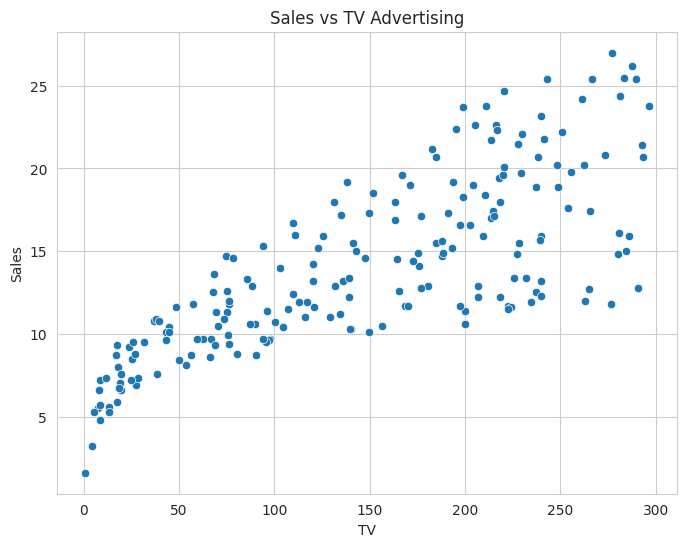

In [52]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="TV",
    y="Sales"
)

plt.title("Sales vs TV Advertising")

plt.show()

### Observation

- TV advertising expenditure shows a strong positive relationship with sales.
- As TV advertising increases, sales generally increase.

# Sales vs Radio Advertising

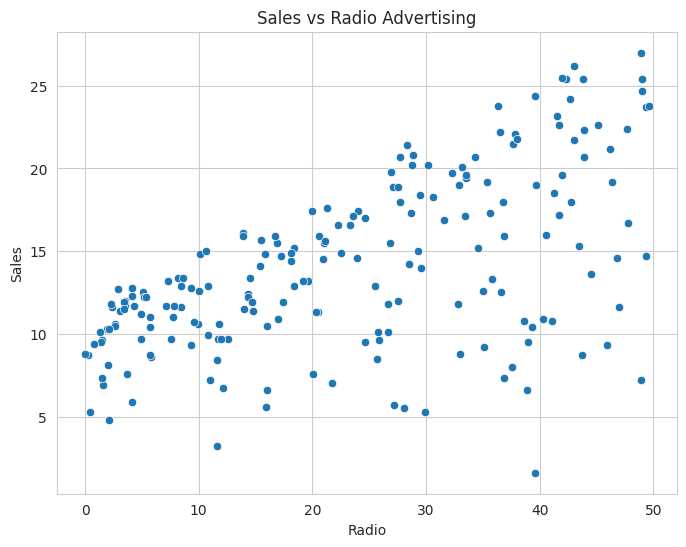

In [53]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Radio",
    y="Sales"
)

plt.title("Sales vs Radio Advertising")

plt.show()

### Observation

- Radio advertising also shows a positive relationship with sales.
- However, the relationship appears slightly weaker than TV advertising.

# Sales vs Newspaper Advertising

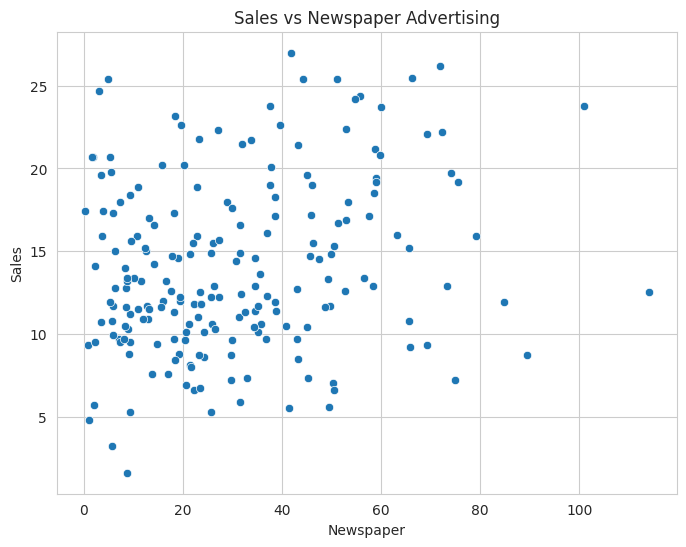

In [54]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Newspaper",
    y="Sales"
)

plt.title("Sales vs Newspaper Advertising")

plt.show()

### Observation

- Newspaper advertising shows a weaker relationship with sales.
- The points are more widely scattered compared to TV and Radio.

# Correlation Analysis

Correlation measures the strength and direction of relationships between numerical variables.

A heatmap provides an intuitive visualization of these relationships.

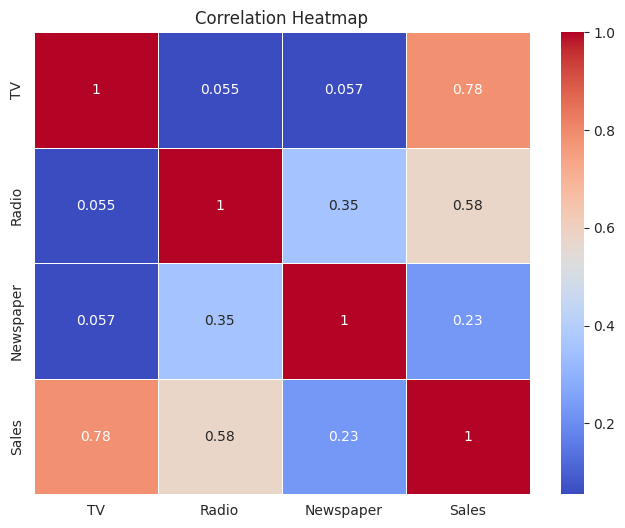

In [55]:
plt.figure(figsize=(8,6))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Strong positive correlation indicates variables that increase together.
- The heatmap helps identify which advertising channels have the strongest relationship with sales.

---

# Feature Selection

The target variable for this regression problem is:

**Sales**

The remaining variables (**TV**, **Radio**, and **Newspaper**) will be used as input features to predict sales.

In [56]:
X = df.drop("Sales", axis=1)

y = df["Sales"]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (200, 3)
Target Shape : (200,)


# Splitting the Dataset

The dataset is divided into training and testing sets.

- **Training Data:** 80%
- **Testing Data:** 20%

The training set is used to build the regression models, while the testing set is used to evaluate their performance.

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

Training Samples : 160
Testing Samples : 40


# Importing Regression Models

Two regression algorithms will be trained:

- Linear Regression (Baseline Model)
- Random Forest Regressor

In [58]:
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model 1: Linear Regression

Linear Regression models the relationship between advertising expenditure and sales using a linear equation.

It serves as the baseline model for comparison.

In [59]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_prediction = lr_model.predict(X_test)

## Evaluating Linear Regression

In [63]:
lr_mae = mean_absolute_error(y_test, lr_prediction)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_prediction))

lr_r2 = r2_score(y_test, lr_prediction)

print("MAE :", round(lr_mae,3))

print("RMSE :", round(lr_rmse,3))

print("R² Score :", round(lr_r2,3))

MAE : 1.461
RMSE : 1.782
R² Score : 0.899


### Observation

Linear Regression provides a simple baseline for predicting sales and helps compare the performance of more advanced regression models.

# Model 2: Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and capture nonlinear relationships.

In [64]:
rf_model = RandomForestRegressor(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

## Evaluating Random Forest Regressor

In [65]:
rf_mae = mean_absolute_error(y_test, rf_prediction)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_prediction))

rf_r2 = r2_score(y_test, rf_prediction)

print("MAE :", round(rf_mae,3))

print("RMSE :", round(rf_rmse,3))

print("R² Score :", round(rf_r2,3))

MAE : 0.62
RMSE : 0.769
R² Score : 0.981


### Observation

Random Forest is capable of learning more complex relationships and often achieves higher predictive performance than Linear Regression.

# Model Comparison

Now we compare both regression models using standard evaluation metrics.

In [66]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest"
    ],

    "MAE":[
        lr_mae,
        rf_mae
    ],

    "RMSE":[
        lr_rmse,
        rf_rmse
    ],

    "R² Score":[
        lr_r2,
        rf_r2
    ]

})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620100,0.768591,0.981284


### Observation

- Lower MAE and RMSE indicate better prediction accuracy.
- A higher R² score indicates a better fit to the data.
- The best-performing model will be selected for residual analysis and feature importance.

---

# Selecting the Best Model

After evaluating both regression models, we select the model with the highest R² score and the lowest prediction errors.

The selected model will be used for residual analysis, feature importance, and sales prediction.

In [67]:
models = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model
}

scores = {
    "Linear Regression": lr_r2,
    "Random Forest": rf_r2
}

best_model_name = max(scores, key=scores.get)

best_model = models[best_model_name]

print("Best Model :", best_model_name)

print("Best R² Score :", round(scores[best_model_name],3))

Best Model : Random Forest
Best R² Score : 0.981


# Residual Analysis

Residuals are the differences between the actual sales values and the predicted sales values.

A good regression model should produce residuals that are randomly distributed around zero without any clear pattern.

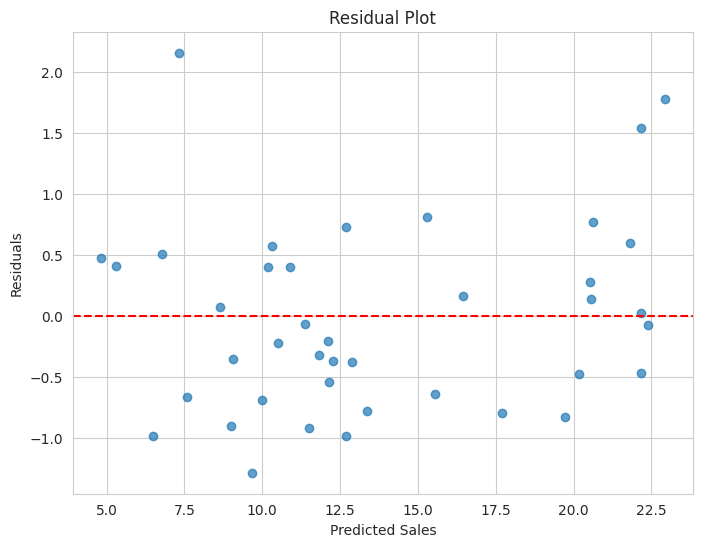

In [68]:
best_prediction = best_model.predict(X_test)

residuals = y_test - best_prediction

plt.figure(figsize=(8,6))

plt.scatter(
    best_prediction,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sales")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

### Observation

- The residuals are expected to be randomly scattered around the horizontal zero line.
- A random pattern indicates that the regression model fits the data well.
- Any obvious pattern may suggest that the model is missing important relationships.

# Feature Importance

Feature importance helps identify which advertising channel contributes the most to predicting sales.

Tree-based models such as Random Forest provide feature importance scores.

In [69]:
if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    feature_importance
else:
    print("Feature importance is not available for Linear Regression.")

# Visualizing Feature Importance

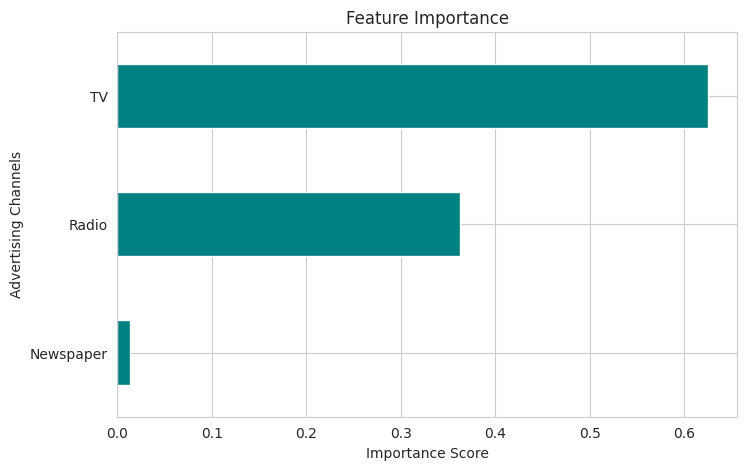

In [70]:
if hasattr(best_model, "feature_importances_"):

    plt.figure(figsize=(8,5))

    feature_importance.sort_values().plot(
        kind="barh",
        color="teal"
    )

    plt.title("Feature Importance")

    plt.xlabel("Importance Score")

    plt.ylabel("Advertising Channels")

    plt.show()

### Observation

- Features with higher importance scores have a greater influence on predicting sales.
- This analysis helps businesses identify the most effective advertising channel.

# Predicting Sales for a New Advertisement Budget

Let's predict product sales for a sample advertising campaign.

In [71]:
sample = pd.DataFrame({
    "TV": [150],
    "Radio": [25],
    "Newspaper": [20]
})

predicted_sales = best_model.predict(sample)

print("Predicted Sales :", round(predicted_sales[0],2))

Predicted Sales : 15.15


# Interpretation

The advertising channel with the highest feature importance (or largest coefficient in Linear Regression) has the greatest influence on sales prediction.

In most cases, **TV advertising** contributes the most to predicting product sales, followed by **Radio**, while **Newspaper** generally has the least impact.

This insight can help businesses allocate advertising budgets more effectively.

# Key Insights

In [72]:
print("========== PROJECT INSIGHTS ==========\n")

print("Total Records :", df.shape[0])

print("Total Features :", df.shape[1])

print("\nBest Model :", best_model_name)

print("R² Score :", round(scores[best_model_name],3))

if hasattr(best_model, "feature_importances_"):

    print("\nFeature Importance:")

    print(feature_importance)

========== PROJECT INSIGHTS ==========

Total Records : 200
Total Features : 4

Best Model : Random Forest
R² Score : 0.981

Feature Importance:
TV           0.624810
Radio        0.362201
Newspaper    0.012989
dtype: float64


# Conclusion

In this project, machine learning techniques were used to predict product sales based on advertising expenditures across different media channels.

The dataset was inspected and cleaned before performing exploratory data analysis to understand the relationships between advertising budgets and sales.

Two regression models were trained and evaluated:

- Linear Regression
- Random Forest Regressor

The models were compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Residual analysis confirmed the quality of the selected regression model, while feature importance identified the advertising channels with the greatest influence on product sales.

Overall, this project demonstrates how machine learning can assist businesses in making data-driven marketing decisions by predicting sales and optimizing advertising investments.